# Atividade de Construção I — A ficha que você teria de defender

**Computação Cognitiva · Ciência de Dados e Negócios · ESPM · 2026.2 · Prof. André Insardi**

**Integrantes**

- <<INTEGRANTES: Nome Sobrenome, Nome Sobrenome, ...>>

> Preencha os nomes acima **e** a lista `INTEGRANTES` na célula de setup (ou regenere
> com `python scripts/build_notebook.py --integrantes "Nome Sobrenome" ...`). O nome
> dos três arquivos de entrega (`AtividadeI_<sobrenomes>`) é derivado dessa lista.

**Declaração de uso de IA (Seção 7).** Usamos assistentes de IA para escrever partes do
código do pacote `ficha` e revisar textos. Todas as decisões de projeto, os números e
as conclusões foram verificados pelo grupo, que sabe explicar cada linha entregue.

**Como ler este notebook.** Toda a lógica (limpeza, seleção, prompt, parse, auditoria,
custo, relatório) vive no pacote testado `src/ficha`; aqui só orquestramos e
mostramos resultados (ADR 0001). Há dois modos:

- `MODO = "ensaio"`: `FakeLLM` determinístico + PDFs sintéticos gerados na hora —
  roda em segundos, sem GPU nem rede, e prova que o pipeline inteiro funciona.
  **Os números do modo ensaio não são resultados da atividade.**
- `MODO = "real"`: os 19 PDFs em `data/raw` + Qwen2.5-3B-Instruct na T4 do Colab
  (ou o backend declarado). É este que gera a entrega.

## 1. Setup

**No Colab, antes de qualquer célula:** *Ambiente de execução → Alterar tipo → GPU T4*
(a troca reinicia a sessão). Depois:

1. suba `ficha.zip` (gerado por `make colab-zip`) para `/content/`;
2. suba os 19 PDFs para `/content/ficha/data/raw/` (ou aponte `RAW_DIR` para o Drive);
3. se for usar API, cadastre a chave nos **Secrets** do Colab (ícone de chave) com o nome
   `ANTHROPIC_API_KEY` — ela é lida para o ambiente **sem ser impressa**.

Sementes fixas em `random`, `numpy` e `torch` (Seção 7, Reprodutibilidade).

In [1]:
import importlib.util
import os
import shutil
import subprocess
import sys
from pathlib import Path

INTEGRANTES = ['<<INTEGRANTES: Nome Sobrenome, Nome Sobrenome, ...>>']
MODO = os.environ.get("FICHA_MODO", "ensaio")  # troque para "real" na entrega
BACKEND_REAL = "qwen_local"  # ou "anthropic" / "openai_compat" (declare no relatório)
RAW_DIR = None  # ex.: Path("/content/drive/MyDrive/artigos") — None = data/raw

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if IN_COLAB:
    ROOT = Path("/content/ficha")
    if not ROOT.exists() and Path("/content/ficha.zip").exists():
        shutil.unpack_archive("/content/ficha.zip", ROOT)
    extras = "local,embeddings,api"
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", f"ficha[{extras}] @ file://{ROOT}"],
        check=True,
    )
else:
    cwd = Path.cwd()
    ROOT = Path(os.environ.get("FICHA_ROOT", cwd.parent if cwd.name == "notebooks" else cwd))
ROOT.mkdir(parents=True, exist_ok=True)
os.chdir(ROOT)

if IN_COLAB:  # chaves: Secrets do Colab → ambiente, nunca impressas
    from google.colab import userdata

    for nome in ("ANTHROPIC_API_KEY", "OPENAI_API_KEY"):
        try:
            valor = userdata.get(nome)
        except Exception:
            valor = None
        if valor:
            os.environ[nome] = valor

from ficha.extract import set_seeds
from ficha.llm.qwen_local import describe_gpu

set_seeds(42)
print(f"MODO={MODO} · Colab={IN_COLAB} · raiz={ROOT}")
print("GPU:", describe_gpu() or "nenhuma (ok no modo ensaio; no modo real use a T4)")
print("Chaves no ambiente (só presença):",
      {n: bool(os.environ.get(n)) for n in ("ANTHROPIC_API_KEY", "OPENAI_API_KEY")})

MODO=ensaio · Colab=False · raiz=/Users/joaomascena/Developer/studies/Atividade Andre


GPU: nenhuma (ok no modo ensaio; no modo real use a T4)
Chaves no ambiente (só presença): {'ANTHROPIC_API_KEY': False, 'OPENAI_API_KEY': False}


## 2. Configuração declarada

Tudo o que o relatório precisa declarar vem de `ficha.config.Settings` (variáveis
`FICHA_*`, `.env` ou Secrets): modelo, temperatura, semente, parâmetros de seleção e a
**premissa de preço** usada na Seção 4.5. Nenhum segredo é impresso.

In [2]:
import json

import pandas as pd
from IPython.display import Image, display

from ficha.config import Settings, get_settings
from ficha.llm import FakeBehavior, build_client

pd.set_option("display.max_colwidth", 120)
if MODO == "ensaio":
    DATA_DIR = ROOT / "data" / "outputs" / "ensaio"
    shutil.rmtree(DATA_DIR, ignore_errors=True)  # ensaio sempre do zero
    settings = get_settings(data_dir=DATA_DIR, model_backend="fake")
    # Erros simulados para a auditoria ter o que encontrar (ver ficha.llm.fake).
    client = build_client(settings, behavior=FakeBehavior(
        broken_json_rate=0.25, invent_trecho_rate=0.2,
        invent_limitacao_rate=0.4, unstable_rate=0.3,
    ))
else:
    settings = get_settings(data_dir=ROOT / "data", model_backend=BACKEND_REAL)
    client = build_client(settings)
settings.ensure_dirs()
FIG_DIR = settings.outputs_dir / "figuras"
FIG_DIR.mkdir(parents=True, exist_ok=True)
count_tokens = client.count_tokens  # tokenizador real no Qwen; ~4 chars/token no fake

print(json.dumps(settings.declaracao(), ensure_ascii=False, indent=2))
print("cliente:", client.model_name)

{
  "modelo": "fake:Qwen/Qwen2.5-3B-Instruct",
  "quantize_4bit": false,
  "temperatura": 0.0,
  "temperatura_alternativa": 0.7,
  "seed": 42,
  "embedding_model": "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
  "premissa_preco_usd_por_mtok": {
    "entrada": 3.0,
    "saida": 15.0,
    "fonte": "Tabela pública Anthropic, Claude Sonnet 4.5, consultada em 2026-09"
  }
}
cliente: fake/deterministic-v1


## 3. Ingestão e limpeza do texto

`ficha.ingest` extrai o texto página a página com `pymupdf` e aplica uma limpeza
determinística e conservadora (Seção 4.1, último parágrafo): remove cabeçalhos e
rodapés repetidos e números de página soltos, desfaz a **hifenização de fim de linha**
(com vocabulário do próprio artigo para não quebrar compostos legítimos como
*state-of-the-art*), reconstrói parágrafos e normaliza espaços. O resultado fica em
cache (`data/processed`, com `sha256`) para que todas as execuções usem o mesmo texto.

In [3]:
from ficha.ingest import load_or_ingest
from ficha.ingest.synthetic import generate_synthetic_corpus
from ficha.report.overview import corpus_frame

raw_dir = Path(RAW_DIR) if RAW_DIR else settings.raw_dir
if MODO == "ensaio":
    artigos = generate_synthetic_corpus(raw_dir, n=6, seed=settings.seed)
    # Gabarito conhecido: quais artigos declaram limitação (null esperado nos demais).
    GABARITO_LIMITACAO = {a.arquivo: a.has_limitations for a in artigos}
else:
    GABARITO_LIMITACAO = None  # sem gabarito: a auditoria usa a heurística declarada

pdfs = sorted(raw_dir.glob("*.pdf"))
assert pdfs, f"Nenhum PDF em {raw_dir}: suba os artigos antes de continuar."
docs = [load_or_ingest(p, settings.processed_dir) for p in pdfs]
corpus = corpus_frame(docs, count_tokens)
display(corpus)
total = corpus.iloc[-1]
print(f"{len(docs)} artigos · {total.paginas} páginas · {total.caracteres:,} caracteres · "
      f"~{total.tokens:,} tokens (enunciado: 19 artigos, ~476 páginas, ~1,4 M chars, ~350 k tokens)")
meta = docs[0].metadata
print({k: meta.get(k) for k in ("n_chars_raw", "n_chars_clean", "empty_pages")})

,arquivo,paginas,caracteres,tokens
0,artigo_01.pdf,3,6852,1714
1,artigo_02.pdf,4,10425,2608
2,artigo_03.pdf,5,13879,3472
3,artigo_04.pdf,4,10567,2643
4,artigo_05.pdf,5,14839,3712
5,artigo_06.pdf,4,10678,2671
6,TOTAL,25,67240,16820


6 artigos · 25 páginas · 67,240 caracteres · ~16,820 tokens (enunciado: 19 artigos, ~476 páginas, ~1,4 M chars, ~350 k tokens)
{'n_chars_raw': 7085, 'n_chars_clean': 6852, 'empty_pages': []}


## 4. O que mandar para o modelo (Seção 4.1)

Três estratégias implementadas, todas com a mesma interface (`ContextSelector`):

| Estratégia | O que envia | Risco |
|---|---|---|
| `first_pages` | as N primeiras páginas | limitações e métricas costumam estar no fim |
| `keyword` | seções achadas por título (*Methods*, *Results*, *Limitations*...) | depende do nome da seção |
| `semantic` | blocos de ~1.200 caracteres (sobreposição de 200) mais próximos de consultas sobre problema, dados, método, métrica e limitação | depende da qualidade do embedding |

**Escolha: `semantic`**, com `keyword` como alternativa (ADR 0002). Blocos de 1.200
caracteres (~300 tokens, um parágrafo típico, a unidade em que autores declaram uma
limitação) com sobreposição de 200 (uma frase inteira: a evidência não é cortada);
8 consultas em português, uma ou duas por campo da ficha — incluindo "como o
desempenho foi medido" e "o que este trabalho não consegue fazer" —, embedder
multilíngue (as consultas são em português, os artigos em inglês) e blocos
reordenados por página. A busca vetorial aqui **não é o produto** — é só o modo de
escolher o que entra no prompt. A verificação 4.4c (seção 8)
testa essa escolha contra `first_pages`. Abaixo: o que cada estratégia envia para um
artigo, e o custo em tokens de cada uma no corpus inteiro.

In [4]:
from ficha.report.overview import selection_frame, strategy_summary
from ficha.select import SELECTOR_NAMES, HashingEmbedder, build_selector

if MODO == "ensaio" or importlib.util.find_spec("sentence_transformers") is None:
    embedder = HashingEmbedder()  # offline, determinístico
    if MODO == "real":
        print("ATENÇÃO: sentence-transformers ausente; usando HashingEmbedder (declare no relatório).")
else:
    embedder = None  # SentenceTransformer multilíngue das Settings
selectors = {nome: build_selector(nome, settings, embedder) for nome in SELECTOR_NAMES}
ESTRATEGIA, ESTRATEGIA_ALT = "semantic", "first_pages"

exemplo = docs[0]
for nome, sel in selectors.items():
    ctx = sel.select(exemplo)
    texto = ctx.render()
    print(f"=== {nome}: páginas {list(ctx.pages)} · {len(ctx.chunks)} trechos · "
          f"{len(texto):,} chars · ~{count_tokens(texto):,} tokens · params={ctx.params}")
    print(texto[:500].rstrip(), "[...]\n")

=== first_pages: páginas [1, 2, 3] · 3 trechos · 6,877 chars · ~1,719 tokens · params={'n_pages': 3, 'max_chars': None, 'truncated': False}
[p. 1]
Predicting Thirty-Day Hospital Readmission from Electronic Health Records

A. Researcher, B. Scientist and C. Analyst · Institute of Data Studies

Abstract

This paper addresses the problem of forecasting hospital readmission within thirty days of discharge. Structured features are combined with TF-IDF representations of discharge notes and fed to a gradient boosted classifier tuned with five-fold cross-validation. Performance is measured by the area under the ROC curve (AUROC) and area u [...]

=== keyword: páginas [1, 2, 3] · 7 trechos · 4,504 chars · ~1,126 tokens · params={'window_chars': 1500, 'max_chars': 6000, 'sections_found': ['Abstract', '3 Data', '4 Methods', '5 Results', '6 Limitations', '7 Discussion', '8 Conclusion'], 'fallback': None, 'sections_selected': ['Abstract', '6 Limitations', '4 Methods', '3 Data', '5 Results', '7 Dis

In [5]:
selecao = selection_frame(docs, list(selectors.values()), count_tokens)
resumo_estrategias = strategy_summary(selecao)
display(resumo_estrategias)

,chunks_medios,caracteres_medios,tokens_medios,tokens_corpus,fracao_media_do_artigo
estrategia,,,,,
first_pages,3.0,9844,2461,14765,0.904
keyword,7.0,4312,1078,6467,0.410
semantic,4.8,6969,1742,10454,0.651


## 5. O prompt (Seção 4.2)

Cada técnica é um bloco com cabeçalho fixo, ligável/desligável por `PromptFeatures`
(ADR 0003): **papel** (`### PAPEL`, na mensagem de sistema), **instrução explícita** e
**formato de saída** com o schema JSON embutido, **delimitadores**
`<<<ARTIGO>>> ... <<<FIM_ARTIGO>>>` com o aviso de que nada ali dentro é ordem,
**few-shot** com dois exemplos — um deles com `limitacao: null` — e **abstenção**
("melhor `null` do que inventado"). A cadeia de raciocínio existe como variante
(`v_cot`, raciocínio num campo separado do JSON), mas não está na versão principal.

**Medição obrigatória:** `v_full` × `v_sem_fewshot` diferem **só** no few-shot.

**Temperatura 0,0.** Extração é tarefa de fidelidade: queremos a saída mais provável e
reprodutível (com semente fixa). A seção 8d mede o que muda com 0,7.

In [6]:
from ficha.prompts import build_prompt, describe_diff

builder = build_prompt("v_full")
rp = builder.render(selectors[ESTRATEGIA].select(exemplo))
print("Blocos presentes:", builder.markers_present(), "· template_sha:", builder.template_sha())
print("\n--- SYSTEM ---\n", rp.system)
print("\n--- USER (início) ---\n", rp.user[:2200], "\n[...]\n", rp.user[-400:])
print("\n", describe_diff("v_full", "v_sem_fewshot"))
print("\nTemperatura:", settings.temperature, "—", Settings.model_fields["temperature"].description)

Blocos presentes: ['### PAPEL', '### INSTRUÇÃO', '### FORMATO DE SAÍDA', '### REGRA DE ABSTENÇÃO', '### EXEMPLOS', '### ARTIGO'] · template_sha: e4ea67f171ac

--- SYSTEM ---
 ### PAPEL
Você é um assistente de pesquisa que prepara fichas de leitura de artigos científicos para uma tabela comparativa. Sua prioridade é a fidelidade ao texto: cada afirmação da ficha precisa poder ser defendida com um trecho do próprio artigo. Você nunca completa lacunas com conhecimento próprio nem com suposições plausíveis.

--- USER (início) ---
 ### INSTRUÇÃO
Leia o texto do artigo enviado abaixo (em inglês) e preencha a ficha, campo a campo:
- "problema": o que o trabalho tenta resolver, em uma frase.
- "dados": que dados usa — fonte, período e volume, quando informados.
- "metodo": a abordagem principal.
- "metrica": como o resultado é medido.
- "limitacao": a limitação que os PRÓPRIOS AUTORES declaram (não a sua opinião sobre o trabalho).
- "evidencia.trecho": um trecho COPIADO LITERALMENTE do texto e

## 6. Extração — matriz de execuções

Cada execução tem um `run_id` e grava **as saídas brutas** do modelo em
`data/runs/<run_id>/records.jsonl` (+ `manifest.json` com modelo, prompt, estratégia,
temperatura e semente). A saída passa por `parse_completion`: JSON validado pelo
schema (`FichaExtraida`, `extra="forbid"`); se vier malformado, tentamos reparos
registrados (cercas de código, vírgula final, aspas tipográficas) e o status fica
`repaired`; se nada funcionar, `failed` — o código trata e segue, não quebra.

| Execução | Prompt | Estratégia | Temperatura | Artigos | Serve para |
|---|---|---|---|---|---|
| a) principal | v_full | semantic | 0,0 | todos | tabela final |
| b) repetição | v_full | semantic | 0,0 | todos | 4.4b estabilidade |
| c) prompt alternativo | v_sem_fewshot | semantic | 0,0 | todos | 4.2 comparação |
| d) entrada alternativa | v_full | first_pages | 0,0 | todos | 4.4c efeito da entrada |
| e) temperatura | v_full | semantic | 0,7 | subconjunto | 4.4d temperatura |

In [7]:
from ficha.extract import ExtractionRunner, RunStore, reparse
from ficha.types import GenerationParams, ParseStatus

store = RunStore(settings.runs_dir)

def rodar(estrategia, variante, temperatura, repeticao, documentos):
    params = GenerationParams(temperature=temperatura, seed=settings.seed,
                              max_new_tokens=settings.max_new_tokens)
    runner = ExtractionRunner(client, selectors[estrategia], build_prompt(variante), params, store)
    res = runner.run(documentos, repetition=repeticao, show_progress=(MODO == "real"))
    print(f"{res.run_id}: {res.status_counts()}")
    return res

SUBCONJUNTO_T = docs[: max(3, len(docs) // 3)]  # 19 artigos → 6
execucoes = {
    "principal": rodar(ESTRATEGIA, "v_full", settings.temperature, 1, docs),
    "repeticao": rodar(ESTRATEGIA, "v_full", settings.temperature, 2, docs),
    "prompt_alt": rodar(ESTRATEGIA, "v_sem_fewshot", settings.temperature, 1, docs),
    "entrada_alt": rodar(ESTRATEGIA_ALT, "v_full", settings.temperature, 1, docs),
    "temperatura_alt": rodar(ESTRATEGIA, "v_full", settings.temperature_alt, 1, SUBCONJUNTO_T),
}
display(pd.DataFrame([
    {"execucao": k, "run_id": r.run_id, **r.status_counts(),
     "json_valido_de_primeira": r.manifest["resumo"]["taxa_json_valido_de_primeira"]}
    for k, r in execucoes.items()
]))

20260923-140750_semantic_v_full_t0.0_rep1: {'ok': 3, 'repaired': 3, 'failed': 0}


20260923-140750_semantic_v_full_t0.0_rep2: {'ok': 3, 'repaired': 3, 'failed': 0}


20260923-140750_semantic_v_sem_fewshot_t0.0_rep1: {'ok': 5, 'repaired': 1, 'failed': 0}
20260923-140750_first_pages_v_full_t0.0_rep1: {'ok': 4, 'repaired': 2, 'failed': 0}
20260923-140750_semantic_v_full_t0.7_rep1: {'ok': 1, 'repaired': 2, 'failed': 0}


,execucao,run_id,ok,repaired,failed,json_valido_de_primeira
0,principal,20260923-140750_semantic_v_full_t0.0_rep1,3,3,0,0.5000
1,repeticao,20260923-140750_semantic_v_full_t0.0_rep2,3,3,0,0.5000
2,prompt_alt,20260923-140750_semantic_v_sem_fewshot_t0.0_rep1,5,1,0,0.8333
3,entrada_alt,20260923-140750_first_pages_v_full_t0.0_rep1,4,2,0,0.6667
4,temperatura_alt,20260923-140750_semantic_v_full_t0.7_rep1,1,2,0,0.3333


Uma saída **bruta** do modelo, exatamente como foi gravada, e um caso que precisou de reparo ou falhou:

In [8]:
registros = execucoes["principal"].records
r0 = next((r for r in registros if r.parse_status == ParseStatus.OK), registros[0])
print(f"[{r0.run_id} · {r0.arquivo} · {r0.parse_status.value}]\n{r0.raw_output[:1500]}")

problemas = [r for res in execucoes.values() for r in res.records if r.parse_status != ParseStatus.OK]
if problemas:
    rp_ = problemas[0]
    print(f"\n[{rp_.run_id} · {rp_.arquivo} · {rp_.parse_status.value}] "
          f"reparos={reparse(rp_).repairs} erro={rp_.error}\n{rp_.raw_output[:1200]}")
else:
    print("\nNenhuma saída precisou de reparo nesta rodada — isso também é resultado.")

[20260923-140750_semantic_v_full_t0.0_rep1 · artigo_03.pdf · ok]
{
  "problema": "Resolver o problema descrito no artigo.",
  "dados": "Dados descritos na seção de dados do artigo.",
  "metodo": "Método principal descrito no artigo.",
  "metrica": "Métrica reportada nos resultados.",
  "limitacao": "O tamanho reduzido da amostra limita a generalização dos resultados.",
  "evidencia": {
    "trecho": "Analyst · Institute of Data Studies\n\nAbstract\n\nThis paper addresses the problem of predicting default of credit card clients in a transparent way.",
    "pagina": 1
  }
}

[20260923-140750_semantic_v_full_t0.0_rep1 · artigo_01.pdf · repaired] reparos=['cercas_de_codigo', 'virgula_final'] erro=None
```json
{
  "problema": "Resolver o problema descrito no artigo.",
  "dados": "Dados descritos na seção de dados do artigo.",
  "metodo": "Método principal descrito no artigo.",
  "metrica": "Métrica reportada nos resultados.",
  "limitacao": null,
  "evidencia": {
    "trecho": "1 Introducti

## 7. Comparação das duas versões do prompt (Seção 4.2)

Mesmos artigos, mesma estratégia, mesma temperatura; só o few-shot muda. Medimos a taxa
de **JSON válido de primeira**, a taxa de **`null` quando a informação não existe**
(no ensaio contra o gabarito dos PDFs sintéticos; no real pela heurística de
vocabulário declarada em `ficha.audit.runstats`), a fidelidade e **em que campos as
fichas discordam**. A versão final sai da regra declarada
(`PromptComparison.decide`: JSON válido → fidelidade → null correto), não da intuição.

,v_full,v_sem_fewshot,delta (b-a)
n,6.000000,6.000000,0.000000
rate_json_valid_first_try,0.500000,0.833333,0.333333
rate_parse_ok,0.500000,0.833333,0.333333
rate_parse_repaired,0.500000,0.166667,-0.333333
rate_parse_failed,0.000000,0.000000,0.000000
rate_limitacao_null,0.666667,0.833333,0.166667
rate_null_when_expected,1.000000,1.000000,0.000000
n_null_expected,3.000000,3.000000,0.000000
rate_fidelity,0.833333,0.833333,0.000000
rate_page_ok,0.833333,0.833333,0.000000


Vencedora: v_sem_fewshot — v_sem_fewshot vence por rate_json_valid_first_try: 0.500 (v_full) vs 0.833 (v_sem_fewshot); critérios anteriores empataram.


,arquivo,field,a,b,equal,similarity
0,artigo_01.pdf,evidencia.trecho,1 Introduction\n\nWe study the problem of forecasting hospital readmission within thirty days of discharge.,Structured features are combined with TF-IDF representations of discharge notes and fed to a gradient boosted classi...,False,0.3954
1,artigo_02.pdf,evidencia.trecho,The proposed framework achieves state-of-the-art results across all benchmarks considered.,Performance is measured by the macro-averaged F1 score and accuracy on a manually annotated test split.,False,0.3938
2,artigo_03.pdf,limitacao,O tamanho reduzido da amostra limita a generalização dos resultados.,NaN,False,0.0000
3,artigo_03.pdf,evidencia.trecho,Analyst · Institute of Data Studies\n\nAbstract\n\nThis paper addresses the problem of predicting default of credit ...,We train monotonic gradient boosting ensembles and compare them with logistic regression using Shapley additive expl...,False,0.3941
4,artigo_04.pdf,evidencia.trecho,Several contributions rely on handcrafted representations whose generalization to unseen institutions remains questi...,Our implementation follows established recommendations for hyperparameter optimization and early stopping.,False,0.4541
5,artigo_05.pdf,evidencia.trecho,Performance is measured by the concordance index (C-index) and the integrated Brier score.,The proposed framework achieves state-of-the-art results across all benchmarks considered.,False,0.3778
6,artigo_06.pdf,evidencia.trecho,The organizational context in which predictions are consumed influences the choice of decision thresholds.,"Performance is measured by the mean absolute error (MAE) at 15, 30 and 60 minute horizons.",False,0.3776


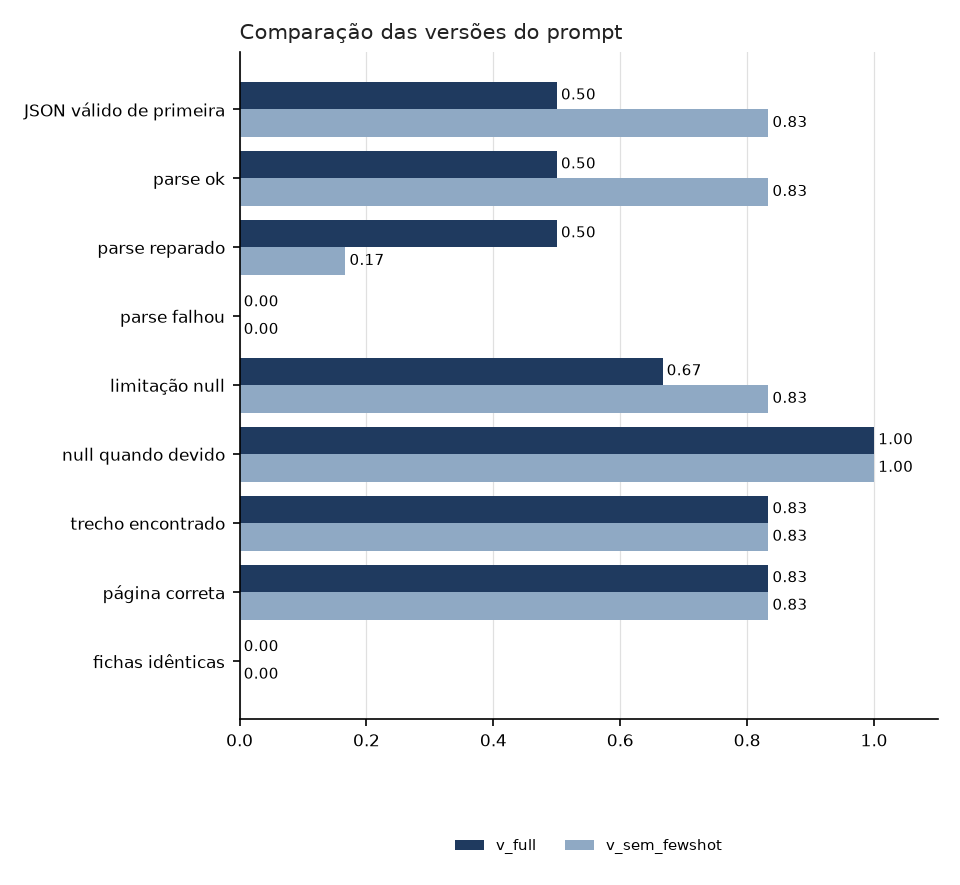

In [9]:
from ficha.audit import compare_prompt_variants
from ficha.report.figures import plot_prompt_comparison

comparacao = compare_prompt_variants(
    execucoes["principal"].records, execucoes["prompt_alt"].records,
    limitacao_gabarito=GABARITO_LIMITACAO,
)
tabela_prompts = comparacao.to_frame()
display(tabela_prompts)
veredito = comparacao.decide()
print("Vencedora:", veredito.winner, "—", veredito.explanation)
divergencias = pd.DataFrame([d.to_dict() for d in comparacao.disagreements()])
display(divergencias.head(10) if not divergencias.empty else "As fichas das duas versões não discordam.")

taxas = tabela_prompts.loc[[i for i in tabela_prompts.index if str(i).startswith("rate_")],
                           list(comparacao.variants)].astype(float)
fig_prompts = plot_prompt_comparison(taxas, FIG_DIR / "comparacao_prompts.png")
display(Image(filename=str(fig_prompts)))
# Versão compacta (só as taxas decisivas) para caber no relatório de 3 páginas.
chave = ["rate_json_valid_first_try", "rate_null_when_expected", "rate_fidelity"]
fig_prompts_relatorio = plot_prompt_comparison(
    taxas.loc[[k for k in chave if k in taxas.index]], FIG_DIR / "comparacao_prompts_relatorio.png"
)

## 8. Auditoria (Seção 4.4)

As quatro verificações, cada uma com números e uma frase de conclusão (ADR 0005).

- **a) Fidelidade** — `evidencia.trecho` é procurado no **texto que foi enviado** ao
  modelo (não no PDF inteiro): substring exata após normalização tipográfica; senão
  `partial_ratio` ≥ 0,90. Também conferimos se a página declarada bate com o marcador
  `[p. N]` onde o trecho está.
- **b) Estabilidade** — execução repetida sem mudar nada; diferença campo a campo.
- **c) Efeito da entrada** — `semantic` × `first_pages` nos mesmos artigos.
- **d) Efeito da temperatura** — 0,0 × 0,7 num subconjunto.

In [10]:
from ficha.audit import build_audit_summary
from ficha.report.assemble import fidelity_block, input_block, stability_block, temperature_block

resumo = build_audit_summary(
    execucoes["principal"].records,
    stability_rep=execucoes["repeticao"].records,
    alt_input=execucoes["entrada_alt"].records,
    t_alt=execucoes["temperatura_alt"].records,
    prompt_runs=(execucoes["principal"].records, execucoes["prompt_alt"].records),
    limitacao_gabarito=GABARITO_LIMITACAO,
)
tabelas = resumo.tables()

def mostrar(bloco):
    print(f"{bloco.titulo}: " + " · ".join(f"{k}: {v}" for k, v in bloco.numeros.items()))
    print("→", bloco.conclusao)

mostrar(fidelity_block(resumo))
display(tabelas["fidelidade"])

a) Fidelidade: trecho encontrado: 5/6 (83%) · página correta: 5/6 · exato / aproximado / sem ficha: 5 / 1 / 0
→ 1 de 6 trechos não existem no texto enviado — tratados como inventados: artigo_02.pdf.


,arquivo,run_id,found,score,method,page_claimed,page_found,page_ok,threshold
0,artigo_01.pdf,20260923-140750_semantic_v_full_t0.0_rep1,True,1.0000,exact,1,1.0,True,0.9
1,artigo_02.pdf,20260923-140750_semantic_v_full_t0.0_rep1,False,0.5444,fuzzy,1,NaN,False,0.9
2,artigo_03.pdf,20260923-140750_semantic_v_full_t0.0_rep1,True,1.0000,exact,1,1.0,True,0.9
3,artigo_04.pdf,20260923-140750_semantic_v_full_t0.0_rep1,True,1.0000,exact,1,1.0,True,0.9
4,artigo_05.pdf,20260923-140750_semantic_v_full_t0.0_rep1,True,1.0000,exact,1,1.0,True,0.9
5,artigo_06.pdf,20260923-140750_semantic_v_full_t0.0_rep1,True,1.0000,exact,1,1.0,True,0.9


Como a fidelidade pega um trecho inventado: o trecho devolvido, o score e o que o texto enviado realmente tinha.

In [11]:
principal = {r.arquivo: r for r in execucoes["principal"].records}
falhas = resumo.fidelity.failures()
for f in falhas[:3]:
    rec = principal[f.arquivo]
    trecho = rec.ficha.evidencia.trecho if rec.ficha else "(sem ficha)"
    print(f"{f.arquivo}: score={f.score:.2f} ({f.method}) — trecho devolvido:\n  «{trecho}»")
    print(f"  início do texto enviado: «{rec.context_text[:300]}...»\n")
if not falhas:
    print("Todos os trechos foram encontrados no texto enviado.")

artigo_02.pdf: score=0.54 (fuzzy) — trecho devolvido:
  «The proposed framework achieves state-of-the-art results across all benchmarks considered.»
  início do texto enviado: «[p. 1]
Aspect-Level Sentiment Classification of Product Reviews

A. Researcher, B. Scientist and C. Analyst · Institute of Data Studies

Abstract

This paper addresses the problem of classifying the sentiment expressed about specific product aspects. A pretrained transformer encoder is fine-tuned wi...»



b) Estabilidade: pares comparados: 6 · fichas idênticas: 6/6 (100%) · campos que mais mudam: nenhum
→ As 6 fichas foram idênticas nas duas execuções.


,field,change_rate,mean_similarity
0,problema,0.0,1.0
1,dados,0.0,1.0
2,metodo,0.0,1.0
3,metrica,0.0,1.0
4,limitacao,0.0,1.0
5,evidencia.trecho,0.0,1.0
6,evidencia.pagina,0.0,1.0


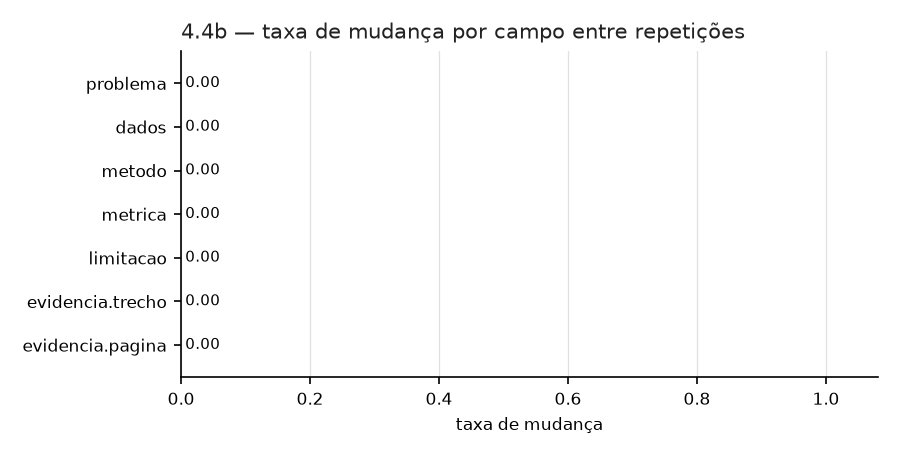

In [12]:
from ficha.report.figures import plot_field_change_rates

mostrar(stability_block(resumo))
display(tabelas["estabilidade_campos"])
fig_estab = plot_field_change_rates(
    tabelas["estabilidade_campos"][["field", "change_rate"]], FIG_DIR / "estabilidade_campos.png",
    title="4.4b — taxa de mudança por campo entre repetições",
)
display(Image(filename=str(fig_estab)))

c) Efeito da entrada: estratégias: semantic × first_pages · fichas idênticas: 0/6 · divergências substantivas: 10 · fidelidade: semantic 83% · first_pages 67% · campos que mais divergem: limitacao 83%, evidencia.trecho 83%, problema 50%
→ Defendemos semantic: semantic vence por maior taxa de fidelidade (0.833 vs 0.667).


,semantic,first_pages
n,6.000000,6.000000
rate_json_valid_first_try,0.500000,0.666667
rate_parse_ok,0.500000,0.666667
rate_parse_repaired,0.500000,0.333333
rate_parse_failed,0.000000,0.000000
rate_limitacao_null,0.666667,0.500000
rate_null_when_expected,1.000000,0.333333
n_null_expected,3.000000,3.000000
rate_fidelity,0.833333,0.666667
rate_page_ok,0.833333,0.666667


,field,change_rate,mean_similarity
0,limitacao,0.833333,0.166667
1,evidencia.trecho,0.833333,0.501400
2,metodo,0.500000,0.923550
3,problema,0.500000,0.928550
4,dados,0.000000,1.000000
5,metrica,0.000000,1.000000
6,evidencia.pagina,0.000000,1.000000


,arquivo,field,a,b,equal,similarity
0,artigo_01.pdf,limitacao,NaN,O tamanho reduzido da amostra limita a generalização dos resultados.,False,0.0000
1,artigo_01.pdf,evidencia.trecho,1 Introduction\n\nWe study the problem of forecasting hospital readmission within thirty days of discharge.,The proposed framework achieves state-of-the-art results across all benchmarks considered.,False,0.3711
2,artigo_02.pdf,limitacao,NaN,O tamanho reduzido da amostra limita a generalização dos resultados.,False,0.0000
3,artigo_02.pdf,evidencia.trecho,The proposed framework achieves state-of-the-art results across all benchmarks considered.,Additional experiments confirmed that the conclusions are consistent across random initializations of the network.,False,0.4118
4,artigo_03.pdf,limitacao,O tamanho reduzido da amostra limita a generalização dos resultados.,NaN,False,0.0000
5,artigo_03.pdf,evidencia.trecho,Analyst · Institute of Data Studies\n\nAbstract\n\nThis paper addresses the problem of predicting default of credit ...,The proposed framework achieves state-of-the-art results across all benchmarks considered.,False,0.3761
6,artigo_04.pdf,limitacao,NaN,O tamanho reduzido da amostra limita a generalização dos resultados.,False,0.0000
7,artigo_04.pdf,evidencia.trecho,Several contributions rely on handcrafted representations whose generalization to unseen institutions remains questi...,Our implementation follows established recommendations for hyperparameter optimization and early stopping.,False,0.4541
8,artigo_05.pdf,limitacao,O tamanho reduzido da amostra limita a generalização dos resultados.,NaN,False,0.0000
9,artigo_06.pdf,evidencia.trecho,The organizational context in which predictions are consumed influences the choice of decision thresholds.,Analyst · Institute of Data Studies\n\nAbstract\n\nThis paper addresses the problem of forecasting traffic speed on ...,False,0.3953


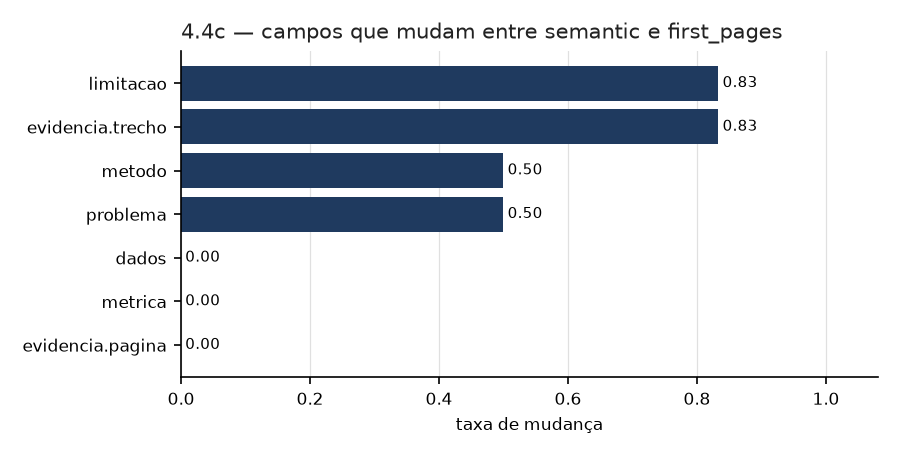

In [13]:
mostrar(input_block(resumo))
display(tabelas["entrada_estrategias"])
display(tabelas["entrada_campos"])
display(tabelas["entrada_divergencias"].head(10))
fig_entrada = plot_field_change_rates(
    tabelas["entrada_campos"][["field", "change_rate"]], FIG_DIR / "entrada_campos.png",
    title=f"4.4c — campos que mudam entre {ESTRATEGIA} e {ESTRATEGIA_ALT}",
)
display(Image(filename=str(fig_entrada)))

In [14]:
mostrar(temperature_block(resumo))
print("Critério declarado:", resumo.temperature.criterio)
display(tabelas["temperatura"])

d) Efeito da temperatura: subconjunto: 3 artigos · JSON válido de primeira: t=0,0: 33% · t=0,7: 33% · fidelidade: t=0,0: 67% · t=0,7: 100% · fichas idênticas: 1/3
→ A escolha de t=0,0 NÃO se sustenta pelo critério declarado: t=0,7 teve validade ou fidelidade maior neste subconjunto — reportado como está.
Critério declarado: A temperatura escolhida se sustenta se, no mesmo subconjunto de artigos, tiver taxa de fidelidade (trecho encontrado no texto enviado) maior ou igual e taxa de JSON válido de primeira maior ou igual às da temperatura alternativa.


,t=0.0,t=0.7
n,3.000000,3.000000
rate_json_valid_first_try,0.333333,0.333333
rate_parse_ok,0.333333,0.333333
rate_parse_repaired,0.666667,0.666667
rate_parse_failed,0.000000,0.000000
rate_limitacao_null,0.666667,0.666667
rate_null_when_expected,0.000000,0.000000
n_null_expected,1.000000,1.000000
rate_fidelity,0.666667,1.000000
rate_page_ok,0.666667,1.000000


## 9. Confiança — regra declarada e fichas que não defenderíamos

`confianca` nunca vem do modelo nem "do olho": é função determinística das verificações
acima (`ficha.audit.ConfidenceRule`). Cada ficha carrega os **motivos** que a
impediram de ter nível mais alto — é deles que sai a lista de fichas não defensáveis.

Regra de confiança (aplicada automaticamente; o nível final é o MENOR entre os limites abaixo):
- BAIXA se a extração falhou (nenhum JSON válido segundo o esquema), ou o trecho de evidência não foi encontrado no texto enviado ao modelo (similaridade partial_ratio normalizada < 0.90), ou o trecho foi encontrado numa página diferente da declarada em evidencia.pagina; ou mais de 2 campos mudaram entre as duas repetições ou entre as duas estratégias de entrada.
- MEDIA se a evidência passou, mas entre 1 e 2 campos mudaram em alguma das comparações (repetição ou estratégia), ou se alguma comparação não pôde ser feita (ausente ou sem ficha válida do outro lado): o que não foi verificado não recebe ALTA.
- No máximo MEDIA se o campo limitacao veio preenchido mas o texto enviado não contém nenhum termo de limitação (limitation, shortcoming, drawback, caveat, future work, threats to validity...), sinal de limitação possivelmente inventada.
- ALTA somente se a evidência foi encontrada na página 

,confianca,n
0,alta,0
1,media,2
2,baixa,4


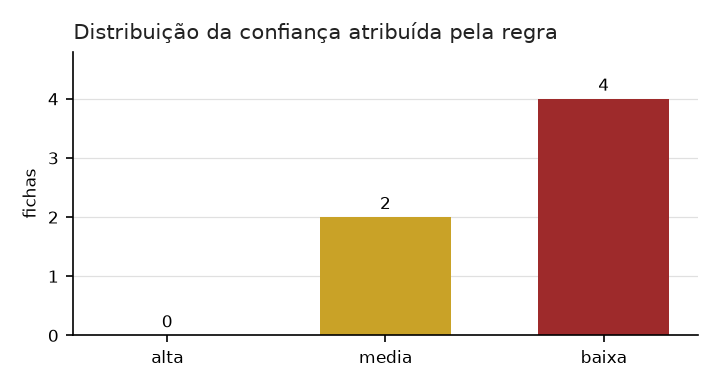

Fichas que NÃO defenderíamos (confiança baixa) e por quê:


,arquivo,confianca,motivos
0,artigo_02.pdf,baixa,trecho não encontrado no texto enviado (score 0.54 < 0.90): possível trecho inventado; 2 campo(s) mudou(aram) entre ...
1,artigo_03.pdf,baixa,"4 campos mudaram entre estratégias de entrada (instável); limitação preenchida, mas o texto enviado não tem vocabulá..."
2,artigo_04.pdf,baixa,4 campos mudaram entre estratégias de entrada (instável)
3,artigo_05.pdf,baixa,3 campos mudaram entre estratégias de entrada (instável)


In [15]:
from ficha.report.figures import plot_confidence_distribution

print(resumo.rule.describe())
display(tabelas["confianca"])
fichas_finais = [f.ficha for f in resumo.fichas]
fig_conf = plot_confidence_distribution(fichas_finais, FIG_DIR / "distribuicao_confianca.png")
display(Image(filename=str(fig_conf)))
print("Fichas que NÃO defenderíamos (confiança baixa) e por quê:")
display(tabelas["nao_defensaveis"])

In [16]:
colunas = ["arquivo", "confianca", "limitacao", "evidencia_pagina", "audit_motivos",
           "audit_fidelity_score", "audit_campos_instaveis", "audit_campos_divergentes_entrada"]
display(tabelas["fichas"][colunas])

,arquivo,confianca,limitacao,evidencia_pagina,audit_motivos,audit_fidelity_score,audit_campos_instaveis,audit_campos_divergentes_entrada
0,artigo_01.pdf,media,NaN,1,2 campo(s) mudou(aram) entre estratégias de entrada,1.0000,,"limitacao, evidencia.trecho"
1,artigo_02.pdf,baixa,NaN,1,trecho não encontrado no texto enviado (score 0.54 < 0.90): possível trecho inventado; 2 campo(s) mudou(aram) entre ...,0.5444,,"limitacao, evidencia.trecho"
2,artigo_03.pdf,baixa,O tamanho reduzido da amostra limita a generalização dos resultados.,1,"4 campos mudaram entre estratégias de entrada (instável); limitação preenchida, mas o texto enviado não tem vocabulá...",1.0000,,"problema, metodo, limitacao, evidencia.trecho"
3,artigo_04.pdf,baixa,NaN,1,4 campos mudaram entre estratégias de entrada (instável),1.0000,,"problema, metodo, limitacao, evidencia.trecho"
4,artigo_05.pdf,baixa,O tamanho reduzido da amostra limita a generalização dos resultados.,1,3 campos mudaram entre estratégias de entrada (instável),1.0000,,"problema, metodo, limitacao"
5,artigo_06.pdf,media,NaN,1,1 campo(s) mudou(aram) entre estratégias de entrada,1.0000,,evidencia.trecho


## 10. Custo (Seção 4.5)

Somamos o `Usage` de **todas** as chamadas feitas (as cinco execuções, inclusive
repetição, prompt alternativo, entrada alternativa e temperatura). A alternativa
ingênua espelha exatamente as mesmas chamadas, trocando o texto selecionado pelo
artigo inteiro. Mesmo com o modelo local gratuito, a premissa de preço (visível abaixo)
responde "quanto isso custaria" num provedor pago.

In [17]:
from ficha.cost import (PricePremise, compare_costs, cost_by_run, cost_of_records,
                        cost_table, naive_cost_from_records)

premissa = PricePremise.from_settings(settings)
todos = [r for res in execucoes.values() for r in res.records]
custo_real = cost_of_records(todos, premissa, label="real (todas as execuções)")
custo_ingenuo = naive_cost_from_records(todos, docs, count_tokens, premissa)
comparacao_custo = compare_costs(custo_real, custo_ingenuo)
custo_por_execucao = cost_by_run(todos, premissa)
print(premissa.describe())
display(cost_table([*custo_por_execucao, custo_real, custo_ingenuo]))
print(comparacao_custo.describe())

Premissa: US$ 3.00 por 1M tokens de entrada e US$ 15.00 por 1M tokens de saída (fonte: Tabela pública Anthropic, Claude Sonnet 4.5, consultada em 2026-09).


,label,n_calls,input_tokens,output_tokens,total_tokens,usd_input,usd_output,usd_total,premissa
0,20260923-140750_first_pages_v_full_t0.0_rep1,6,25816,674,26490,0.077448,0.010110,0.087558,"Premissa: US$ 3.00 por 1M tokens de entrada e US$ 15.00 por 1M tokens de saída (fonte: Tabela pública Anthropic, Cla..."
1,20260923-140750_semantic_v_full_t0.0_rep1,6,21502,661,22163,0.064506,0.009915,0.074421,"Premissa: US$ 3.00 por 1M tokens de entrada e US$ 15.00 por 1M tokens de saída (fonte: Tabela pública Anthropic, Cla..."
2,20260923-140750_semantic_v_full_t0.0_rep2,6,21502,661,22163,0.064506,0.009915,0.074421,"Premissa: US$ 3.00 por 1M tokens de entrada e US$ 15.00 por 1M tokens de saída (fonte: Tabela pública Anthropic, Cla..."
3,20260923-140750_semantic_v_full_t0.7_rep1,3,10690,330,11020,0.032070,0.004950,0.037020,"Premissa: US$ 3.00 por 1M tokens de entrada e US$ 15.00 por 1M tokens de saída (fonte: Tabela pública Anthropic, Cla..."
4,20260923-140750_semantic_v_sem_fewshot_t0.0_rep1,6,16568,634,17202,0.049704,0.009510,0.059214,"Premissa: US$ 3.00 por 1M tokens de entrada e US$ 15.00 por 1M tokens de saída (fonte: Tabela pública Anthropic, Cla..."
5,real (todas as execuções),27,96078,2960,99038,0.288234,0.044400,0.332634,"Premissa: US$ 3.00 por 1M tokens de entrada e US$ 15.00 por 1M tokens de saída (fonte: Tabela pública Anthropic, Cla..."
6,"ingênuo (artigo inteiro, mesmas chamadas)",27,119859,2960,122819,0.359577,0.044400,0.403977,"Premissa: US$ 3.00 por 1M tokens de entrada e US$ 15.00 por 1M tokens de saída (fonte: Tabela pública Anthropic, Cla..."


Enviar o artigo inteiro custaria US$ 0.4040 contra US$ 0.3326 efetivamente gastos: 1.2x mais caro (1.2x mais tokens de entrada). Premissa: US$ 3.00 por 1M tokens de entrada e US$ 15.00 por 1M tokens de saída (fonte: Tabela pública Anthropic, Claude Sonnet 4.5, consultada em 2026-09).


## 11. Tabela comparativa (entregável 2)

Uma linha por artigo, com **todos** os campos da ficha na ordem da Seção 3, mais a
coluna `motivos_confianca`. CSV em UTF-8 com BOM (abre certo no Excel pt-BR) e XLSX
formatado. `limitacao = null` vira célula vazia.

In [18]:
from ficha.report import delivery_basename, write_table

BASENAME = delivery_basename(INTEGRANTES)
extras = {f.arquivo: {"motivos_confianca": f.motivos} for f in resumo.fichas}
saidas = write_table(fichas_finais, settings.outputs_dir, basename=BASENAME, extras=extras)
print("CSV :", saidas.csv)
print("XLSX:", saidas.xlsx)
display(pd.read_csv(saidas.csv, encoding="utf-8-sig").head())

CSV : /Users/joaomascena/Developer/studies/Atividade Andre/data/outputs/ensaio/outputs/AtividadeI_SOBRENOMES.csv
XLSX: /Users/joaomascena/Developer/studies/Atividade Andre/data/outputs/ensaio/outputs/AtividadeI_SOBRENOMES.xlsx


,arquivo,problema,dados,metodo,metrica,limitacao,evidencia_trecho,evidencia_pagina,confianca,motivos_confianca
0,artigo_01.pdf,Resolver o problema descrito no artigo.,Dados descritos na seção de dados do artigo.,Método principal descrito no artigo.,Métrica reportada nos resultados.,NaN,1 Introduction\n\nWe study the problem of forecasting hospital readmission within thirty days of discharge.,1,media,2 campo(s) mudou(aram) entre estratégias de entrada
1,artigo_02.pdf,Resolver o problema descrito no artigo.,Dados descritos na seção de dados do artigo.,Método principal descrito no artigo.,Métrica reportada nos resultados.,NaN,The proposed framework achieves state-of-the-art results across all benchmarks considered.,1,baixa,trecho não encontrado no texto enviado (score 0.54 < 0.90): possível trecho inventado; 2 campo(s) mudou(aram) entre ...
2,artigo_03.pdf,Resolver o problema descrito no artigo.,Dados descritos na seção de dados do artigo.,Método principal descrito no artigo.,Métrica reportada nos resultados.,O tamanho reduzido da amostra limita a generalização dos resultados.,Analyst · Institute of Data Studies\n\nAbstract\n\nThis paper addresses the problem of predicting default of credit ...,1,baixa,"4 campos mudaram entre estratégias de entrada (instável); limitação preenchida, mas o texto enviado não tem vocabulá..."
3,artigo_04.pdf,Resolver o problema descrito no artigo.,Dados descritos na seção de dados do artigo.,Método principal descrito no artigo.,Métrica reportada nos resultados.,NaN,Several contributions rely on handcrafted representations whose generalization to unseen institutions remains questi...,1,baixa,4 campos mudaram entre estratégias de entrada (instável)
4,artigo_05.pdf,Resolver o problema descrito no artigo (variante 4).,Dados descritos na seção de dados do artigo.,Método principal descrito no artigo (variante 4).,Métrica reportada nos resultados.,O tamanho reduzido da amostra limita a generalização dos resultados.,Performance is measured by the concordance index (C-index) and the integrated Brier score.,1,baixa,3 campos mudaram entre estratégias de entrada (instável)


## 12. Relatório PDF (entregável 3, ≤ 3 páginas)

O relatório é montado **a partir dos objetos acima** (`ficha.report.assemble`): nenhum
número é digitado à mão. Os textos de justificativa vêm de `Narrative` (resumo dos
ADRs); depois de ler os resultados reais, o grupo revisa e sobrescreve o que quiser —
inclusive as conclusões de cada verificação (`Narrative(conclusoes={...})`). A geração
conta as páginas e falha alto se passar de 3.

In [19]:
from ficha.report import build_report_pdf, count_pages
from ficha.report.assemble import Narrative, build_report_content
from ficha.report.pdf import ReportTooLongError

narrativa = Narrative()  # edite aqui: Narrative(conclusoes={"fidelidade": "..."}, ...)
gpu = describe_gpu()
MODELO_DECLARADO = client.model_name + (f" · {gpu['nome']}" if gpu else "")
if MODO == "ensaio":
    MODELO_DECLARADO += " (MODO ENSAIO: FakeLLM + PDFs sintéticos — não é resultado)"
conteudo = build_report_content(
    integrantes=INTEGRANTES,
    modelo=MODELO_DECLARADO,
    summary=resumo,
    cost=comparacao_custo,
    cost_per_run=custo_por_execucao,
    strategy_table=resumo_estrategias[["caracteres_medios", "tokens_medios", "tokens_corpus"]],
    narrative=narrativa,
    figuras=[fig_prompts_relatorio],
)
pdf_path = settings.outputs_dir / f"{BASENAME}.pdf"
try:
    build_report_pdf(conteudo, pdf_path)
    print(f"PDF: {pdf_path} · {count_pages(pdf_path)} página(s)")
except ReportTooLongError as exc:
    print("ATENÇÃO — relatório longo demais, encurte a narrativa:", exc)

PDF: /Users/joaomascena/Developer/studies/Atividade Andre/data/outputs/ensaio/outputs/AtividadeI_SOBRENOMES.pdf · 2 página(s)


## 13. Checklist de entrega

- [ ] `MODO = "real"` e os 19 PDFs em `data/raw` (a tabela da seção 3 mostra 19 linhas).
- [ ] Integrantes preenchidos na **primeira célula** e em `INTEGRANTES`; o PDF traz os
      nomes na primeira página.
- [ ] Os três arquivos nomeados `AtividadeI_<sobrenomes>`: este notebook (renomeie o
      `.ipynb`), `data/outputs/AtividadeI_<sobrenomes>.csv`/`.xlsx` e `.pdf`.
- [ ] **Ambiente de execução → Reiniciar e executar tudo**, sem erro, com as saídas
      visíveis — só então baixar o `.ipynb`.
- [ ] O PDF tem no máximo 3 páginas (a seção 12 imprime o número).
- [ ] Nenhuma chave no notebook: só Secrets do Colab/variáveis de ambiente (a célula de
      setup imprime apenas se a chave existe).
- [ ] As conclusões do relatório foram revisadas pelo grupo em `Narrative(...)` e cada
      frase é defensável com um número deste notebook.
- [ ] As saídas brutas (`data/runs/`) foram guardadas.